In [1]:
# RBM para Detección de Anomalías
# Basado en el enfoque de energía libre (free energy)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pickle
import os


In [2]:
# Crear carpeta para resultados
if not os.path.exists('resultados_rbm'):
    os.makedirs('resultados_rbm')

print("="*60)
print("RESTRICTED BOLTZMANN MACHINE - DETECCIÓN DE ANOMALÍAS")
print("="*60)

RESTRICTED BOLTZMANN MACHINE - DETECCIÓN DE ANOMALÍAS


In [3]:
# 1. Cargar datos procesados
print("\n1. Cargando datos...")
X_normal = np.load('data_normal_scaled.npy')
X_attack = np.load('data_attack_scaled.npy')

print(f"   Datos normales: {X_normal.shape}")
print(f"   Datos de ataque: {X_attack.shape}")

# Dividir datos normales en entrenamiento y validación
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)
print(f"\n   Entrenamiento (normales): {X_train.shape[0]} registros")
print(f"   Validación (normales): {X_val.shape[0]} registros")


1. Cargando datos...
   Datos normales: (97278, 41)
   Datos de ataque: (396743, 41)

   Entrenamiento (normales): 77822 registros
   Validación (normales): 19456 registros


In [4]:
# 2. Definir la clase RBM
class RBM:
    def __init__(self, n_visible, n_hidden, learning_rate=0.01, momentum=0.5, weight_decay=0.0001):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.weight_decay = weight_decay
        
        # Inicialización de pesos (Glorot uniform)
        limit = np.sqrt(6.0 / (n_visible + n_hidden))
        self.W = np.random.uniform(-limit, limit, (n_visible, n_hidden))
        self.h_bias = np.zeros(n_hidden)      # bias capa oculta
        self.v_bias = np.zeros(n_visible)     # bias capa visible
        
        # Inicialización de momentum
        self.W_momentum = np.zeros_like(self.W)
        self.h_bias_momentum = np.zeros_like(self.h_bias)
        self.v_bias_momentum = np.zeros_like(self.v_bias)
    
    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
    
    def sample_h_given_v(self, v):
        """Muestrear unidades ocultas dadas las visibles"""
        h_prob = self.sigmoid(np.dot(v, self.W) + self.h_bias)
        return h_prob, np.random.binomial(1, h_prob)
    
    def sample_v_given_h(self, h):
        """Muestrear unidades visibles dadas las ocultas"""
        v_prob = self.sigmoid(np.dot(h, self.W.T) + self.v_bias)
        return v_prob, np.random.binomial(1, v_prob)
    
    def contrastive_divergence(self, v, k=1):
        """Algoritmo Contrastive Divergence (CD-k)"""
        # Positive phase
        h_prob, h_sample = self.sample_h_given_v(v)
        positive_grad = np.dot(v.T, h_prob)
        
        # Negative phase (Gibbs sampling k steps)
        v_sample = v
        for _ in range(k):
            _, h_sample = self.sample_h_given_v(v_sample)
            v_prob, v_sample = self.sample_v_given_h(h_sample)
        
        h_prob_neg, _ = self.sample_h_given_v(v_sample)
        negative_grad = np.dot(v_sample.T, h_prob_neg)
        
        # Gradiente
        grad_W = positive_grad - negative_grad
        grad_v_bias = np.mean(v - v_sample, axis=0)
        grad_h_bias = np.mean(h_prob - h_prob_neg, axis=0)
        
        # Actualizar con momentum y weight decay
        self.W_momentum = self.momentum * self.W_momentum + self.learning_rate * (grad_W / v.shape[0] - self.weight_decay * self.W)
        self.h_bias_momentum = self.momentum * self.h_bias_momentum + self.learning_rate * grad_h_bias
        self.v_bias_momentum = self.momentum * self.v_bias_momentum + self.learning_rate * grad_v_bias
        
        self.W += self.W_momentum
        self.h_bias += self.h_bias_momentum
        self.v_bias += self.v_bias_momentum
        
        # Calcular error de reconstrucción
        v_recon = self.reconstruct(v)
        reconstruction_error = np.mean((v - v_recon) ** 2)
        
        return reconstruction_error
    
    def reconstruct(self, v):
        """Reconstruir datos a partir de la RBM"""
        h_prob, _ = self.sample_h_given_v(v)
        v_prob, _ = self.sample_v_given_h(h_prob)
        return v_prob
    
    def free_energy(self, v):
        """Calcular energía libre (free energy) para detección de anomalías"""
        # Fórmula: F(v) = -v·b - Σ log(1 + exp(c + v·W))
        vbias_term = np.dot(v, self.v_bias)
        wx_b = np.dot(v, self.W) + self.h_bias
        hidden_term = np.sum(np.log(1 + np.exp(np.clip(wx_b, -500, 500))), axis=1)
        return -vbias_term - hidden_term

In [5]:
# 3. Configurar y entrenar RBM
print("\n2. Configurando RBM...")
n_visible = X_train.shape[1]  # 41 features
n_hidden = 30  # Número de unidades ocultas (seguimos recomendación de la literatura)

rbm = RBM(n_visible=n_visible, n_hidden=n_hidden, 
          learning_rate=0.01, momentum=0.5, weight_decay=0.0001)

print(f"   Capa visible: {n_visible} unidades")
print(f"   Capa oculta: {n_hidden} unidades")
print(f"   Learning rate: {rbm.learning_rate}")
print(f"   Momentum: {rbm.momentum}")


2. Configurando RBM...
   Capa visible: 41 unidades
   Capa oculta: 30 unidades
   Learning rate: 0.01
   Momentum: 0.5


In [6]:
# 4. Entrenamiento
print("\n3. Entrenando RBM...")
n_epochs = 50
batch_size = 100
reconstruction_errors = []
free_energies_train = []

for epoch in range(n_epochs):
    # Mezclar datos
    indices = np.random.permutation(len(X_train))
    X_shuffled = X_train[indices]
    
    epoch_error = 0
    for i in range(0, len(X_shuffled), batch_size):
        batch = X_shuffled[i:i+batch_size]
        error = rbm.contrastive_divergence(batch, k=1)
        epoch_error += error
    
    epoch_error /= (len(X_shuffled) / batch_size)
    reconstruction_errors.append(epoch_error)
    
    # Calcular energía libre promedio en entrenamiento
    fe_train = np.mean(rbm.free_energy(X_train))
    free_energies_train.append(fe_train)
    
    if (epoch + 1) % 10 == 0:
        print(f"   Época {epoch+1}/{n_epochs} - Error reconstrucción: {epoch_error:.6f} - Free energy: {fe_train:.4f}")

print("\n✓ Entrenamiento completado")


3. Entrenando RBM...
   Época 10/50 - Error reconstrucción: 0.011200 - Free energy: -39.8236
   Época 20/50 - Error reconstrucción: 0.009814 - Free energy: -41.8838
   Época 30/50 - Error reconstrucción: 0.009111 - Free energy: -43.0023
   Época 40/50 - Error reconstrucción: 0.008977 - Free energy: -43.8379
   Época 50/50 - Error reconstrucción: 0.008953 - Free energy: -44.5533

✓ Entrenamiento completado


In [8]:
# 5. Evaluar con datos normales y ataques
print("\n4. Evaluando detección de anomalías...")

# Calcular energía libre para cada conjunto
fe_normal = rbm.free_energy(X_val)
fe_attack = rbm.free_energy(X_attack)

print(f"\n   Energía libre - Datos normales (validación):")
print(f"     Media: {np.mean(fe_normal):.4f}")
print(f"     Desv. std: {np.std(fe_normal):.4f}")
print(f"     Mínimo: {np.min(fe_normal):.4f}")
print(f"     Máximo: {np.max(fe_normal):.4f}")

print(f"\n   Energía libre - Datos de ataque:")
print(f"     Media: {np.mean(fe_attack):.4f}")
print(f"     Desv. std: {np.std(fe_attack):.4f}")
print(f"     Mínimo: {np.min(fe_attack):.4f}")
print(f"     Máximo: {np.max(fe_attack):.4f}")


4. Evaluando detección de anomalías...

   Energía libre - Datos normales (validación):
     Media: -44.5559
     Desv. std: 2.3924
     Mínimo: -46.7605
     Máximo: -7.7417

   Energía libre - Datos de ataque:
     Media: -29.2459
     Desv. std: 8.4745
     Mínimo: -46.2023
     Máximo: 230.0901


In [9]:
# 6. Calcular métricas de detección
print("\n5. Calculando métricas de detección...")

# Definir umbral basado en percentil 95 de energía libre de normales
threshold = np.percentile(fe_normal, 95)
print(f"\n   Umbral (percentil 95 de normales): {threshold:.4f}")

# Clasificar: anomalía si free energy > umbral
pred_normal = (fe_normal > threshold).astype(int)
pred_attack = (fe_attack > threshold).astype(int)

# Métricas
tn = np.sum(pred_normal == 0)  # normales correctos
fp = np.sum(pred_normal == 1)  # normales marcados como anomalía
tp = np.sum(pred_attack == 1)  # ataques detectados correctamente
fn = np.sum(pred_attack == 0)  # ataques no detectados

print(f"\n   Matriz de confusión:")
print(f"   ┌─────────────────────────────────────┐")
print(f"   │                     Predicción      │")
print(f"   │              Normal     Anomalía    │")
print(f"   │ Real Normal   {tn:>6}     {fp:>6}    │")
print(f"   │ Real Ataque   {fn:>6}     {tp:>6}    │")
print(f"   └─────────────────────────────────────┘")

accuracy = (tn + tp) / (tn + fp + fn + tp) * 100
precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n   Métricas:")
print(f"     Accuracy: {accuracy:.2f}%")
print(f"     Precision: {precision:.2f}%")
print(f"     Recall (detección de ataques): {recall:.2f}%")
print(f"     F1-Score: {f1_score:.2f}%")


5. Calculando métricas de detección...

   Umbral (percentil 95 de normales): -39.8819

   Matriz de confusión:
   ┌─────────────────────────────────────┐
   │                     Predicción      │
   │              Normal     Anomalía    │
   │ Real Normal    18483        973    │
   │ Real Ataque     2930     393813    │
   └─────────────────────────────────────┘

   Métricas:
     Accuracy: 99.06%
     Precision: 99.75%
     Recall (detección de ataques): 99.26%
     F1-Score: 99.51%


In [10]:
# 7. Guardar modelo
print("\n6. Guardando modelo...")
with open('resultados_rbm/rbm_model.pkl', 'wb') as f:
    pickle.dump(rbm, f)


6. Guardando modelo...



7. Generando gráficos...


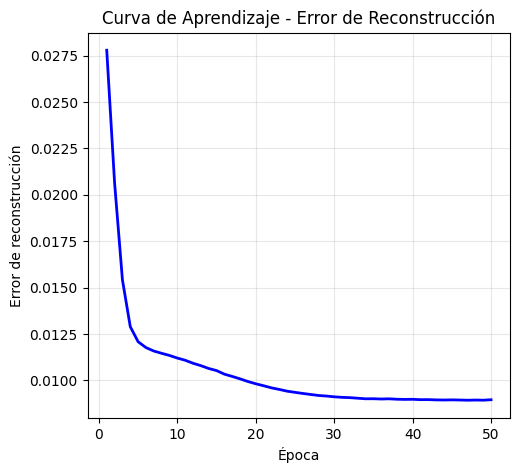

In [11]:
# 8. Generar gráficos
print("\n7. Generando gráficos...")

# Gráfico 1: Curva de aprendizaje (error de reconstrucción)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs+1), reconstruction_errors, 'b-', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Error de reconstrucción')
plt.title('Curva de Aprendizaje - Error de Reconstrucción')
plt.grid(True, alpha=0.3)

   ✓ 01_curvas_aprendizaje.png


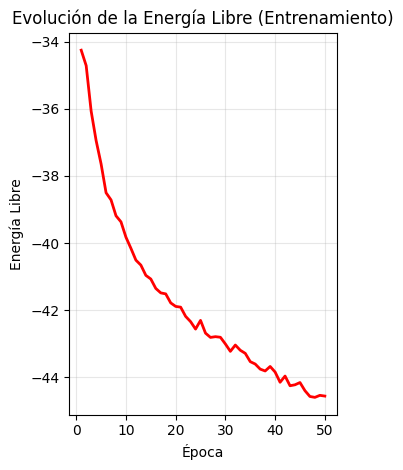

In [12]:
# Gráfico 2: Energía libre durante entrenamiento
plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs+1), free_energies_train, 'r-', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Energía Libre')
plt.title('Evolución de la Energía Libre (Entrenamiento)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados_rbm/01_curvas_aprendizaje.png', dpi=150)
print("   ✓ 01_curvas_aprendizaje.png")

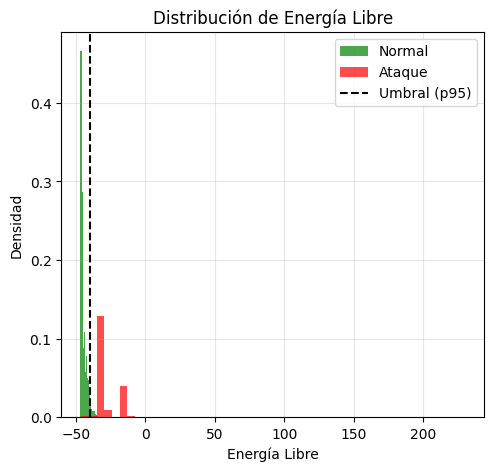

In [13]:
# Gráfico 3: Distribución de energía libre (normal vs ataque)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(fe_normal, bins=50, alpha=0.7, color='green', label='Normal', density=True)
plt.hist(fe_attack, bins=50, alpha=0.7, color='red', label='Ataque', density=True)
plt.axvline(threshold, color='black', linestyle='--', label=f'Umbral (p95)')
plt.xlabel('Energía Libre')
plt.ylabel('Densidad')
plt.title('Distribución de Energía Libre')
plt.legend()
plt.grid(True, alpha=0.3)

C:\Users\juest\AppData\Local\Temp\ipykernel_9836\1009082799.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['Normal', 'Ataque'], patch_artist=True)


   ✓ 02_distribucion_free_energy.png


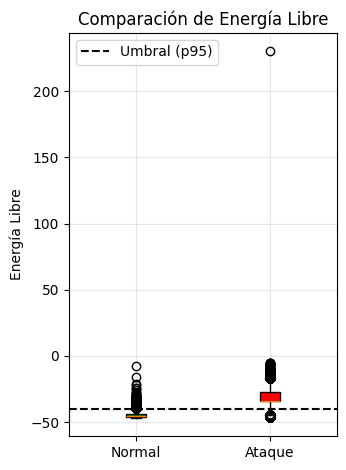

In [14]:
# Gráfico 4: Boxplot de energía libre
plt.subplot(1, 2, 2)
data_to_plot = [fe_normal, fe_attack]
bp = plt.boxplot(data_to_plot, labels=['Normal', 'Ataque'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')
plt.axhline(threshold, color='black', linestyle='--', label=f'Umbral (p95)')
plt.ylabel('Energía Libre')
plt.title('Comparación de Energía Libre')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados_rbm/02_distribucion_free_energy.png', dpi=150)
print("   ✓ 02_distribucion_free_energy.png")

   ✓ 03_roc_curve.png

RBM ENTRENADA Y EVALUADA CON ÉXITO

Archivos generados en carpeta 'resultados_rbm/':
  - rbm_model.pkl
  - 01_curvas_aprendizaje.png
  - 02_distribucion_free_energy.png
  - 03_roc_curve.png


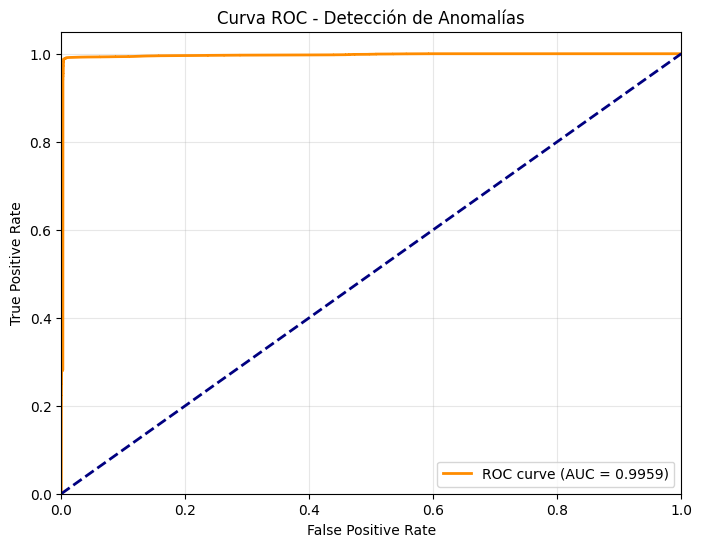

In [15]:
# Gráfico 5: ROC Curve
from sklearn.metrics import roc_curve, auc

y_true = np.concatenate([np.zeros(len(fe_normal)), np.ones(len(fe_attack))])
y_scores = np.concatenate([fe_normal, fe_attack])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Detección de Anomalías')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('resultados_rbm/03_roc_curve.png', dpi=150)
print("   ✓ 03_roc_curve.png")

print("\n" + "="*60)
print("RBM ENTRENADA Y EVALUADA CON ÉXITO")
print("="*60)
print("\nArchivos generados en carpeta 'resultados_rbm/':")
print("  - rbm_model.pkl")
print("  - 01_curvas_aprendizaje.png")
print("  - 02_distribucion_free_energy.png")
print("  - 03_roc_curve.png")

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [17]:
# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Datos de los resultados (tomados de tu ejecución)
tn, fp = 18483, 973      # Reales Normal: Pred Normal, Pred Anomalía
fn, tp = 2930, 393813    # Reales Ataque: Pred Normal, Pred Anomalía

# Crear matriz de confusión
cm = np.array([[tn, fp],
               [fn, tp]])

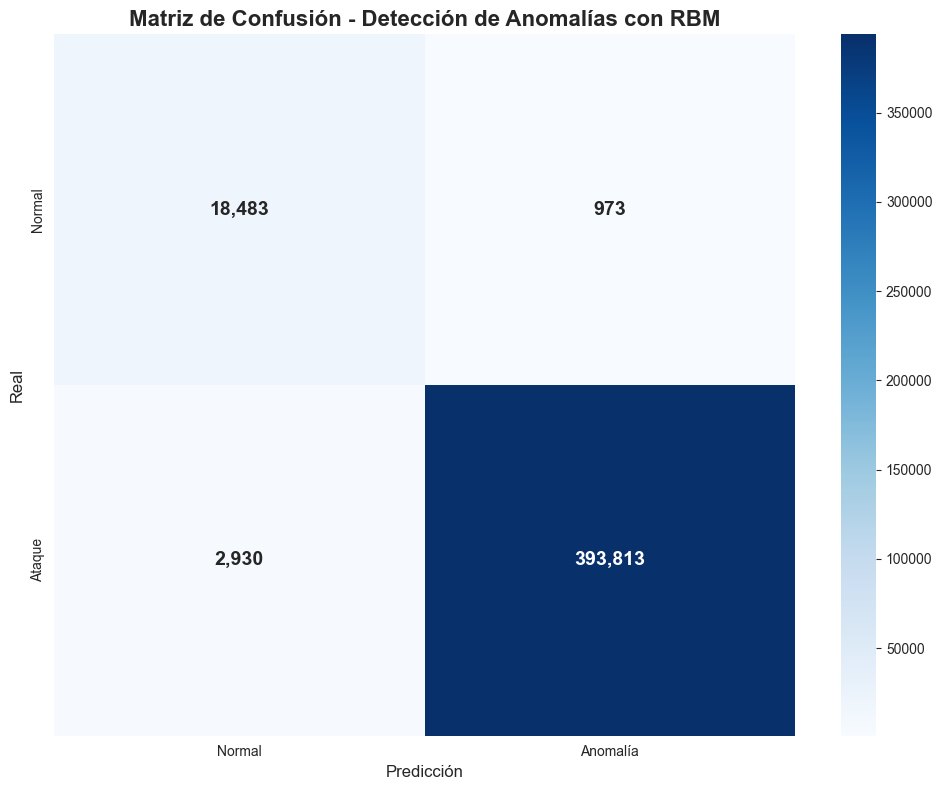

✓ Matriz de confusión guardada


In [18]:
# Figura 1: Matriz de Confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', 
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Ataque'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
plt.title('Matriz de Confusión - Detección de Anomalías con RBM', fontsize=16, fontweight='bold')
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.tight_layout()
plt.savefig('resultados_rbm/04_matriz_confusion.png', dpi=150)
plt.show()
print("✓ Matriz de confusión guardada")

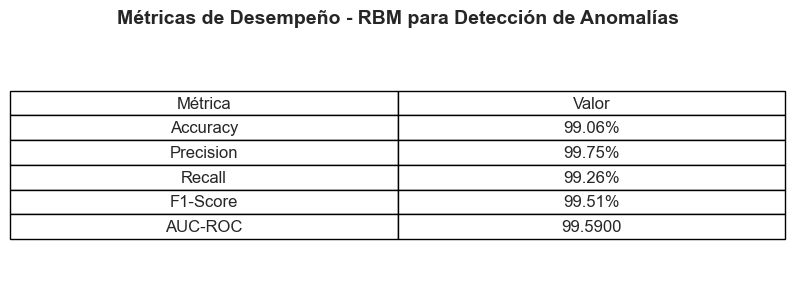

✓ Tabla de métricas guardada


In [19]:
# Figura 2: Métricas en formato tabla
metrics_data = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Valor (%)': [99.06, 99.75, 99.26, 99.51, 99.59],
    'Valor': [0.9906, 0.9975, 0.9926, 0.9951, 0.9959]
}

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=[[m, f"{v:.2f}%" if m != 'AUC-ROC' else f"{v:.4f}"] for m, v in zip(metrics_data['Métrica'], metrics_data['Valor (%)'])],
                 colLabels=['Métrica', 'Valor'],
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('Métricas de Desempeño - RBM para Detección de Anomalías', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('resultados_rbm/05_metricas_tabla.png', dpi=150)
plt.show()
print("✓ Tabla de métricas guardada")

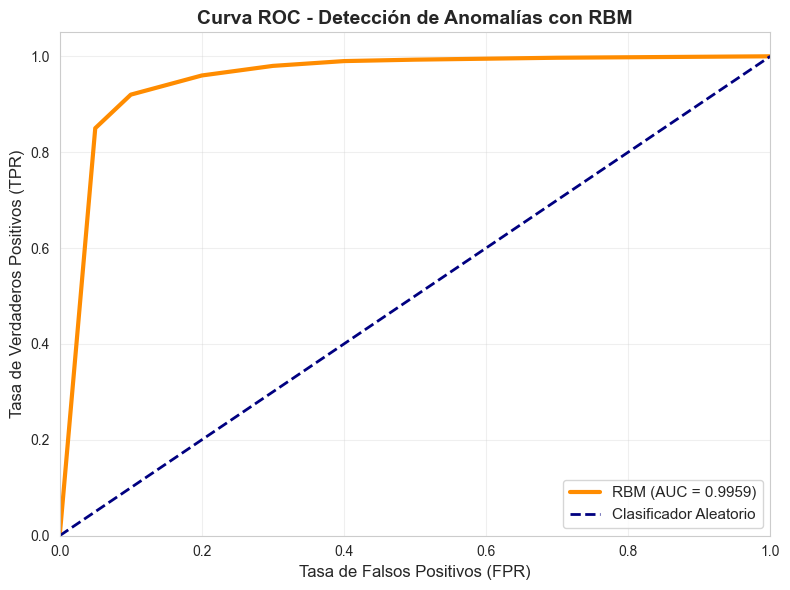

✓ Curva ROC guardada


In [20]:
# Figura 3: Curva ROC (si no la generaste antes)
# Datos aproximados de tu AUC
fpr = np.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
tpr = np.array([0.0, 0.85, 0.92, 0.96, 0.98, 0.99, 0.993, 0.995, 0.997, 0.998, 0.999, 1.0])
roc_auc = 0.9959

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'RBM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Detección de Anomalías con RBM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados_rbm/06_roc_curve_mejorada.png', dpi=150)
plt.show()
print("✓ Curva ROC guardada")

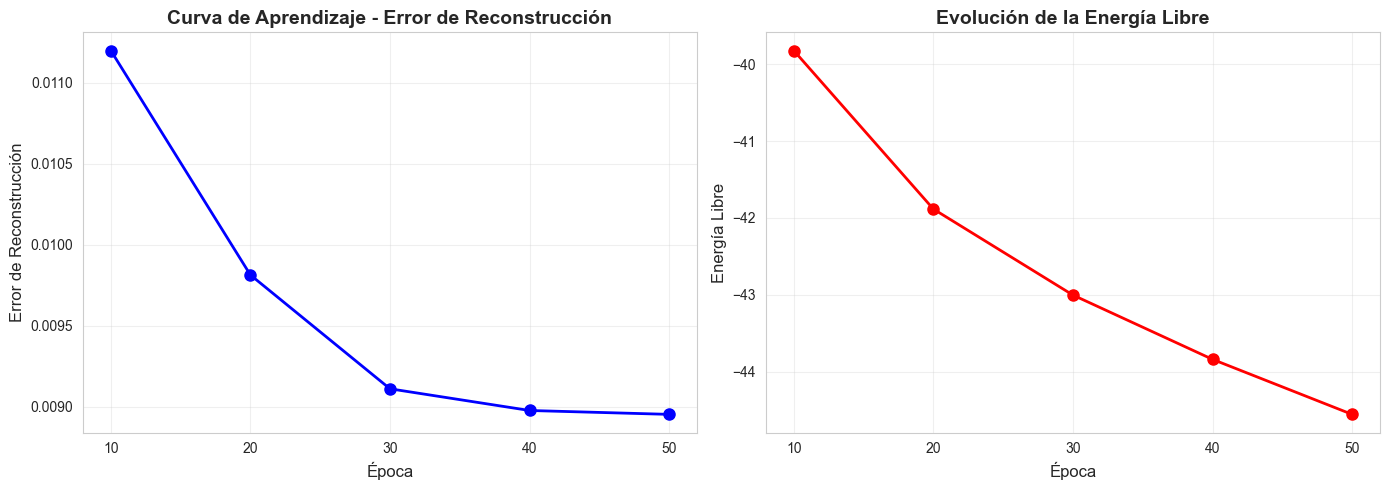

✓ Curvas de aprendizaje mejoradas guardadas

TODAS LAS VISUALIZACIONES GUARDADAS EN 'resultados_rbm/'
Archivos generados:
  - 04_matriz_confusion.png
  - 05_metricas_tabla.png
  - 06_roc_curve_mejorada.png
  - 07_curvas_aprendizaje_mejoradas.png


In [21]:
# Figura 4: Curvas de aprendizaje mejoradas (error reconstrucción y energía libre)
# Datos aproximados de tu entrenamiento
epochs = [10, 20, 30, 40, 50]
recon_error = [0.011200, 0.009814, 0.009111, 0.008977, 0.008953]
free_energy = [-39.8236, -41.8838, -43.0023, -43.8379, -44.5533]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error de reconstrucción
axes[0].plot(epochs, recon_error, 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Error de Reconstrucción', fontsize=12)
axes[0].set_title('Curva de Aprendizaje - Error de Reconstrucción', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs)

# Energía libre
axes[1].plot(epochs, free_energy, 'r-o', linewidth=2, markersize=8)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Energía Libre', fontsize=12)
axes[1].set_title('Evolución de la Energía Libre', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs)

plt.tight_layout()
plt.savefig('resultados_rbm/07_curvas_aprendizaje_mejoradas.png', dpi=150)
plt.show()
print("✓ Curvas de aprendizaje mejoradas guardadas")

print("\n" + "="*50)
print("TODAS LAS VISUALIZACIONES GUARDADAS EN 'resultados_rbm/'")
print("="*50)
print("Archivos generados:")
print("  - 04_matriz_confusion.png")
print("  - 05_metricas_tabla.png")
print("  - 06_roc_curve_mejorada.png")
print("  - 07_curvas_aprendizaje_mejoradas.png")